In [10]:
import pandas as pd
import geopandas as gpd

In [6]:
df = pd.read_csv("data/raw/202602-citibike-tripdata_1.csv")

C:\Users\rqg886\AppData\Local\Temp\ipykernel_28896\367235485.py:1: DtypeWarning: Columns (0: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/raw/202602-citibike-tripdata_1.csv")


In [7]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,8CA3B6A78AF59CA5,electric_bike,2026-02-06 17:20:08.324,2026-02-06 17:24:21.584,Bond St & Bergen St,4404.10,Amity St & Court St,4488.10,40.684967,-73.986208,40.688419,-73.993142,member
1,C6426029C22F971F,electric_bike,2026-02-04 12:02:28.817,2026-02-04 12:10:27.340,Norman Ave & Leonard St,5666.11,Jackson Ave & 49 Ave,6170.09,40.725819,-73.950815,40.742930,-73.952037,member
2,D29833A48B94FDC8,electric_bike,2026-02-11 19:37:21.253,2026-02-11 19:43:18.957,E 2 St & Ave C,5476.03,E 2 St & 2 Ave,5593.02,40.720874,-73.980858,40.725029,-73.990697,member
3,45FCBB4F298A024E,electric_bike,2026-02-01 12:31:54.323,2026-02-01 12:39:24.020,St James Pl & Oliver St,5238.05,E 2 St & 2 Ave,5593.02,40.713079,-73.998512,40.725029,-73.990697,member
4,3E2B396559BECD35,classic_bike,2026-02-13 05:49:37.127,2026-02-13 06:09:27.904,W 20 St & 7 Ave,6182.02,W 13 St & 5 Ave,5947.04,40.742388,-73.997262,40.735445,-73.994310,member


In [22]:
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])


In [27]:
hourly_long = ( # one row per station-hour that had at least one ride
    df.assign(hour=df["started_at"].dt.floor("1h"))
      .groupby(["start_station_id", "hour"])
      .size()
      .rename("rides")
      .reset_index()
)

full_range = pd.date_range(
    hourly_long["hour"].min(), hourly_long["hour"].max(), freq="1h"
)

hourly_wide = ( # station × hour matrix
    hourly_long.pivot(index="start_station_id", columns="hour", values="rides")
               .reindex(columns=full_range)
               .fillna(0)
               .astype(int)
)

print("long:", hourly_long.shape, " wide (stations x hours):", hourly_wide.shape)
hourly_wide.head()

long: (410654, 3)  wide (stations x hours): (2212, 697)


,2026-01-30 23:00:00,2026-01-31 00:00:00,2026-01-31 01:00:00,2026-01-31 02:00:00,2026-01-31 03:00:00,2026-01-31 04:00:00,2026-01-31 05:00:00,2026-01-31 06:00:00,2026-01-31 07:00:00,2026-01-31 08:00:00,...,2026-02-28 14:00:00,2026-02-28 15:00:00,2026-02-28 16:00:00,2026-02-28 17:00:00,2026-02-28 18:00:00,2026-02-28 19:00:00,2026-02-28 20:00:00,2026-02-28 21:00:00,2026-02-28 22:00:00,2026-02-28 23:00:00
start_station_id,,,,,,,,,,,,,,,,,,,,,
1234.56,0,0,0,0,0,0,0,0,0,0,...,2,1,0,0,0,0,0,0,0,1
1964.01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2009.04,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2042.01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2086.07,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
df.ride_id.nunique()

1000000

In [11]:
stations = (
    df[["start_station_id", "start_station_name", "start_lat", "start_lng"]]
    .dropna()
    .drop_duplicates(subset="start_station_id")
    .rename(columns={
        "start_station_id": "station_id",
        "start_station_name": "station_name",
        "start_lat": "lat",
        "start_lng": "lng",
    })
    .reset_index(drop=True)
)

stations_gdf = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations["lng"], stations["lat"]),
    crs="EPSG:4326",
)
stations_gdf.head()

,station_id,station_name,lat,lng,geometry
0,4404.10,Bond St & Bergen St,40.684967,-73.986208,POINT (-73.98621 40.68497)
1,5666.11,Norman Ave & Leonard St,40.725819,-73.950815,POINT (-73.95082 40.72582)
2,5476.03,E 2 St & Ave C,40.720874,-73.980858,POINT (-73.98086 40.72087)
3,5238.05,St James Pl & Oliver St,40.713079,-73.998512,POINT (-73.99851 40.71308)
4,6182.02,W 20 St & 7 Ave,40.742388,-73.997262,POINT (-73.99726 40.74239)


In [20]:
stations_gdf.station_id.nunique()

2212

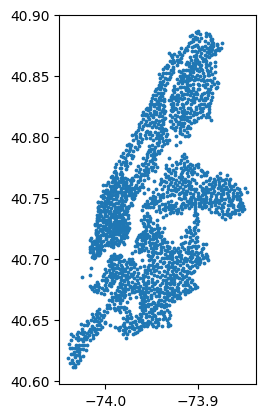

In [19]:
stations_gdf.plot(markersize=3);